# Interaction Detection with GBM
## Setup 
### Import Python Packages 

In [46]:
import os 
import xgboost as xgb
import pandas as pd 
import numpy as np 
import random 
import pyarrow.parquet as pq
import sys
# import shutil
import pickle
import warnings
from itertools import chain
import torch
from sklearn.metrics import mean_absolute_percentage_error
import graphviz
from scipy.stats import pearsonr

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

import optuna
from optuna.visualization import matplotlib as optunampl

# Internal packages 
sys.path.append("../")
from src import utils

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 260)
warnings.filterwarnings("ignore")

### Set Variables

In [2]:
# Fontsize for visualisation
tick_fontsize = 14
label_fontsize = 18
title_fontsize = 22

# Define utility columns
exposure = "Policies_Exposed"
holdout = "holdout"
random_fold = "random_fold"
num_fold = 5

# Define actual and expected death count columns in the data
act_death = "Death_Count"
exp_death = "ExpDth_VBT2015_Cnt"
exp_death_mi = "ExpDth_VBT2015wMI_Cnt"
gam_rel_death = "ypred_death_count_rel"

# Data
data_file = "export/Modelling_data (Filtered, Synchronised Attained_Age and Grouped by Selected Features).parquet"
sf_pred_file = "export/Single Factor Model Predictions.parquet"

# Define the modelling log that records key metrics in this notebook
modelling_log = f"output/03_model_note_xgb_interaction_detection.xlsx"

# Define the name of the residual GBM model
xgb_output = f"output/residual_xgb.json"

## Create Modelling Data

In [3]:
# Import the modelling data
model_data = pd.read_parquet(data_file)
# Import the single factor GAM predictions
ypred_df = pd.read_parquet(sf_pred_file)
# Join the GAM predictions onto the modelling data
model_data = model_data.join(ypred_df[gam_rel_death])
model_data

,Observation_Year,Sex,Smoker_Status,Insurance_Plan,Duration,Face_Amount_Band,Attained_Age_Sync,Amount_Exposed,Policies_Exposed,Death_Claim_Amount,Death_Count,ExpDth_VBT2015_Cnt,ExpDth_VBT2015wMI_Cnt,Sex_cat_level,Smoker_Status_cat_level,Face_Amount_Band_ordinal,holdout,random_fold,act_death_rate,exp_death_rate,exp_death_rate_mi,ypred_death_count_rel
unique_id,,,,,,,,,,,,,,,,,,,,,,
0,2012,M,NS,Term,7,"10: 5,000,000 - 9,999,999",53,4.769294e+08,85.221704,0.0,0.0,0.128005,0.130487,1,0,10,0,2,0.000000,0.001502,0.001531,0.112280
1,2012,M,NS,Term,10,"11: 10,000,000+",59,1.964895e+08,16.607149,0.0,0.0,0.050614,0.051595,1,0,11,0,3,0.000000,0.003048,0.003107,0.032906
2,2012,M,NS,Term,11,"06: 250,000 - 499,999",48,1.988205e+09,6664.746140,2050000.0,8.0,7.494563,7.639922,1,0,6,0,1,0.001200,0.001125,0.001146,7.279165
3,2012,M,NS,Term,7,"04: 50,000 - 99,999",53,1.419839e+07,227.479668,75000.0,1.0,0.341435,0.348057,1,0,4,0,5,0.004396,0.001501,0.001530,0.597216
4,2012,M,NS,Term,6,"02: 10,000 - 24,999",55,2.500000e+05,13.977978,0.0,0.0,0.024675,0.025154,1,0,2,0,5,0.000000,0.001765,0.001800,0.052774
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
575749,2015,F,S,Term,19,"01: 0 - 9,999",88,5.109048e+02,0.304110,0.0,0.0,0.038315,0.038315,0,1,1,0,1,0.000000,0.125990,0.125990,0.061297
575750,2019,M,S,Term,24,"07: 500,000 - 999,999",70,1.835616e+05,0.367123,0.0,0.0,0.010632,0.010363,1,1,7,1,6,0.000000,0.028960,0.028228,0.008339
575751,2012,F,S,Term,26,"06: 250,000 - 499,999",68,7.718575e+04,0.308743,0.0,0.0,0.006070,0.006158,0,1,6,0,1,0.000000,0.019660,0.019945,0.004717


In [4]:
# Check the null rates 
model_data.isnull().sum()

Observation_Year            0
Sex                         0
Smoker_Status               0
Insurance_Plan              0
Duration                    0
Face_Amount_Band            0
Attained_Age_Sync           0
Amount_Exposed              0
Policies_Exposed            0
Death_Claim_Amount          0
Death_Count                 0
ExpDth_VBT2015_Cnt          0
ExpDth_VBT2015wMI_Cnt       0
Sex_cat_level               0
Smoker_Status_cat_level     0
Face_Amount_Band_ordinal    0
holdout                     0
random_fold                 0
act_death_rate              0
exp_death_rate              0
exp_death_rate_mi           0
ypred_death_count_rel       0
dtype: int64

In [5]:
###########################################################################
###########################################################################

# Define the list of numerical features
num_feat = [
    "Observation_Year", 
    "Duration", 
    "Attained_Age_Sync", 
    "Face_Amount_Band_ordinal"
]

# Define the list of categorical features
cat_feat = ["Sex_cat_level", "Smoker_Status_cat_level"]

###########################################################################
###########################################################################

# Define the full feature list 
all_feat = num_feat + cat_feat
print(all_feat)

['Observation_Year', 'Duration', 'Attained_Age_Sync', 'Face_Amount_Band_ordinal', 'Sex_cat_level', 'Smoker_Status_cat_level']


### Encode categorical variables

In [6]:
cat_feat_encoded = []
cat_feat_encoded_all = []
cat_feat_raw = [x.replace("_cat_level", "") for x in cat_feat]

for var in cat_feat_raw: 
    if len(model_data[var].unique()) > 2: 
        cat_feat_encoded.append(var + "_cat_level")
        for level in model_data[var].unique(): 
            model_data[f"{var}.{str(level)}"] = np.where(
                model_data[var] == level, 1, 0
            )
            cat_feat_encoded_all.append(f"{var}.{str(level)}")

print(cat_feat_encoded)
print(cat_feat_encoded_all)

['Smoker_Status_cat_level']
['Smoker_Status.NS', 'Smoker_Status.S', 'Smoker_Status.U']


In [7]:
# Define the final factor list used in GBM
final_feature_gbm = (
    num_feat + [x for x in cat_feat if x not in cat_feat_encoded] + cat_feat_encoded_all
)
print(final_feature_gbm)

['Observation_Year', 'Duration', 'Attained_Age_Sync', 'Face_Amount_Band_ordinal', 'Sex_cat_level', 'Smoker_Status.NS', 'Smoker_Status.S', 'Smoker_Status.U']


### Define required dataframes

In [8]:
# Define the training and holdout dataframes
X_train = model_data.loc[model_data[holdout] == 0, final_feature_gbm]
y_train = model_data.loc[model_data[holdout] == 0, act_death]
w_train = model_data.loc[model_data[holdout] == 0, exposure]
start_train = model_data.loc[model_data[holdout] == 0, gam_rel_death]

X_test = model_data.loc[model_data[holdout] == 1, final_feature_gbm]
y_test = model_data.loc[model_data[holdout] == 1, act_death]
w_test = model_data.loc[model_data[holdout] == 1, exposure]
start_test = model_data.loc[model_data[holdout] == 1, gam_rel_death]

# Define the cross-validation folds required for hyperparameter tuning
random_fold_values = model_data.loc[model_data[holdout] == 0, random_fold].values

# Define a list of tuples, each first element contains indices for the training fold and each second element contains indices for the holdout
folds = []
df_ = pd.DataFrame(
    zip(range(len(random_fold_values)), random_fold_values),
    columns=["row_index", random_fold],
)

for i in range(max(random_fold_values)):
    index_train = df_[df_[random_fold] != i + 1]["row_index"].to_list()
    index_valid = df_[df_[random_fold] == i + 1]["row_index"].to_list()
    folds.append((index_train, index_valid))

valid_folds = [k[1] for k in folds]
check = np.sort(np.array(list(chain(*valid_folds)))) == np.arange(len(X_train))

assert check.sum() == len(
    X_train
), "Not all the rows in the training data are included in the data folds."

In [9]:
# Define the data matrices for XGB training 
dtrain = xgb.DMatrix(
    data=X_train,
    label=y_train, 
    base_margin=np.log(start_train),
)
dtest = xgb.DMatrix(
    data=X_test, 
    label=y_test, 
    base_margin=np.log(start_test)
)

## XGB Training 
### Hyperparameter Tuning  using Optuna

In [10]:
###########################################################################
###########################################################################

has_cuda = torch.cuda.is_available()
eta = 0.05
tree_method = "hist"
device = "cuda" if has_cuda else "cpu"
xgb_objective = "count:poisson"
metric = "poisson-nloglik"
seed = 1997
num_boost_round = 10000 
early_stopping_round = 30
n_trials = 50

###########################################################################
###########################################################################

print(device)

cuda


In [11]:
# Define an objective function for Optuna 
def objective(trial): 
    params = {
        "eta": eta, 
        "min_child_weight": trial.suggest_int(
            "min_child_weight", 1, 1e3, log=True
        ),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5, 1),
        "subsample": trial.suggest_float("subsample", 0.5, 1),
        "gamma": trial.suggest_float("gamma", 1e-6, 1.0, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 2),
        "tree_method": tree_method, 
        "device": device,
        "objective": xgb_objective,
        "eval_metric": metric,
        "seed": seed,
    }

    xgb_cv = xgb.cv(
        dtrain=dtrain, 
        params=params, 
        seed=seed, 
        num_boost_round=num_boost_round, 
        metrics=metric, 
        early_stopping_rounds=early_stopping_round, 
        folds=folds,
    )
    return xgb_cv[f"test-{metric}-mean"].min()

In [73]:
study = optuna.create_study(direction="minimize")

[I 2026-01-12 00:16:41,324] A new study created in memory with name: no-name-afcba865-771e-43b8-a016-0077539cc349


In [ ]:
study.optimize(objective, n_trials=n_trials)

[I 2026-01-12 00:18:08,052] Trial 0 finished with value: 0.5667296910276328 and parameters: {'min_child_weight': 288, 'colsample_bytree': 0.5717319826679502, 'colsample_bylevel': 0.5508265243215318, 'subsample': 0.7536923308567589, 'gamma': 0.004578268792446842, 'max_depth': 2}. Best is trial 0 with value: 0.5667296910276328.
[I 2026-01-12 00:19:02,113] Trial 1 finished with value: 0.5666062054941694 and parameters: {'min_child_weight': 103, 'colsample_bytree': 0.7609503750603988, 'colsample_bylevel': 0.6751424995218209, 'subsample': 0.6996102404678102, 'gamma': 0.0141307498921268, 'max_depth': 2}. Best is trial 1 with value: 0.5666062054941694.
[I 2026-01-12 00:20:01,666] Trial 2 finished with value: 0.5666771436563353 and parameters: {'min_child_weight': 1, 'colsample_bytree': 0.6548778271007614, 'colsample_bylevel': 0.9178246547174853, 'subsample': 0.7642511649897474, 'gamma': 2.776622287649968e-05, 'max_depth': 2}. Best is trial 1 with value: 0.5666062054941694.
[I 2026-01-12 00:21

In [ ]:
# Print best trial
best_trial_number = study.best_trial.number
best_trial_value = study.best_trial.value
print(f"Best trial: {best_trial_number} with value {best_trial_value}\n{'*'*80}")

# Print out the best parameters
best_hyperparams = study.best_params
print(best_hyperparams)

Best trial: 36 with value 0.0672055219201041
********************************************************************************
{'min_child_weight': 1, 'colsample_bytree': 0.6511057744464545, 'colsample_bylevel': 0.9103184988755141, 'subsample': 0.973261455063948, 'gamma': 3.5965554139512857e-06, 'max_depth': 2}


In [ ]:
# Save the tuning progress
with pd.ExcelWriter(
    f"{modelling_log}", engine="openpyxl"
) as writer:
    study.trials_dataframe().sort_values("value").to_excel(
        writer, sheet_name="XGB_Tune", index=False
    )

<Axes: title={'center': 'Empirical Distribution Function Plot'}, xlabel='Objective Value', ylabel='Cumulative Probability'>

<Figure size 640x480 with 0 Axes>

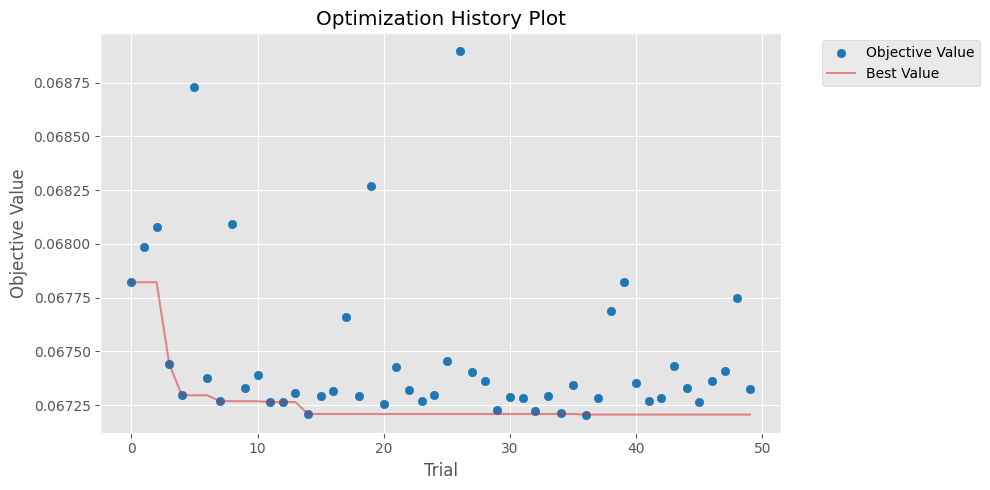

<Figure size 1000x500 with 0 Axes>

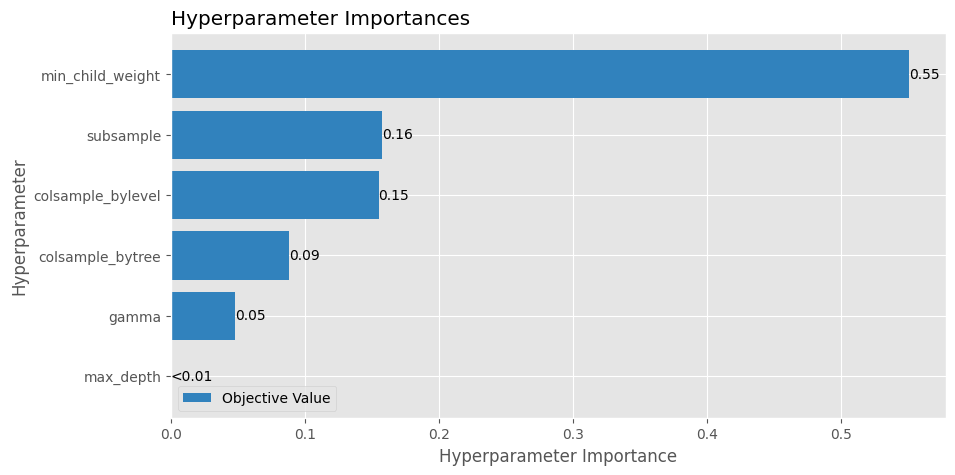

<Figure size 1000x500 with 0 Axes>

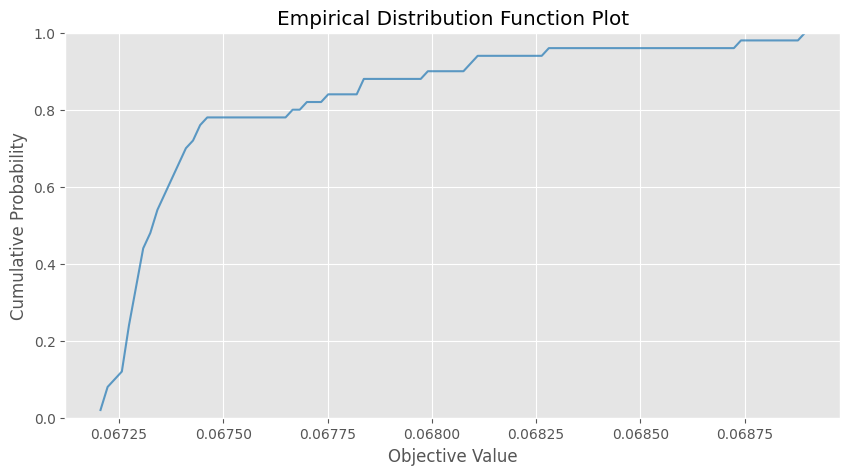

In [ ]:
plt.figure()
plt.rcParams["figure.figsize"] = [10, 5]
optunampl.plot_optimization_history(study)

plt.figure()
plt.rcParams["figure.figsize"] = [10, 5]
optunampl.plot_param_importances(study)

plt.figure()
plt.rcParams["figure.figsize"] = [10, 5]
optunampl.plot_edf(study)

array([<Axes: xlabel='colsample_bylevel', ylabel='Objective Value'>,
       <Axes: xlabel='min_child_weight'>, <Axes: xlabel='subsample'>],
      dtype=object)

<Figure size 1000x500 with 0 Axes>

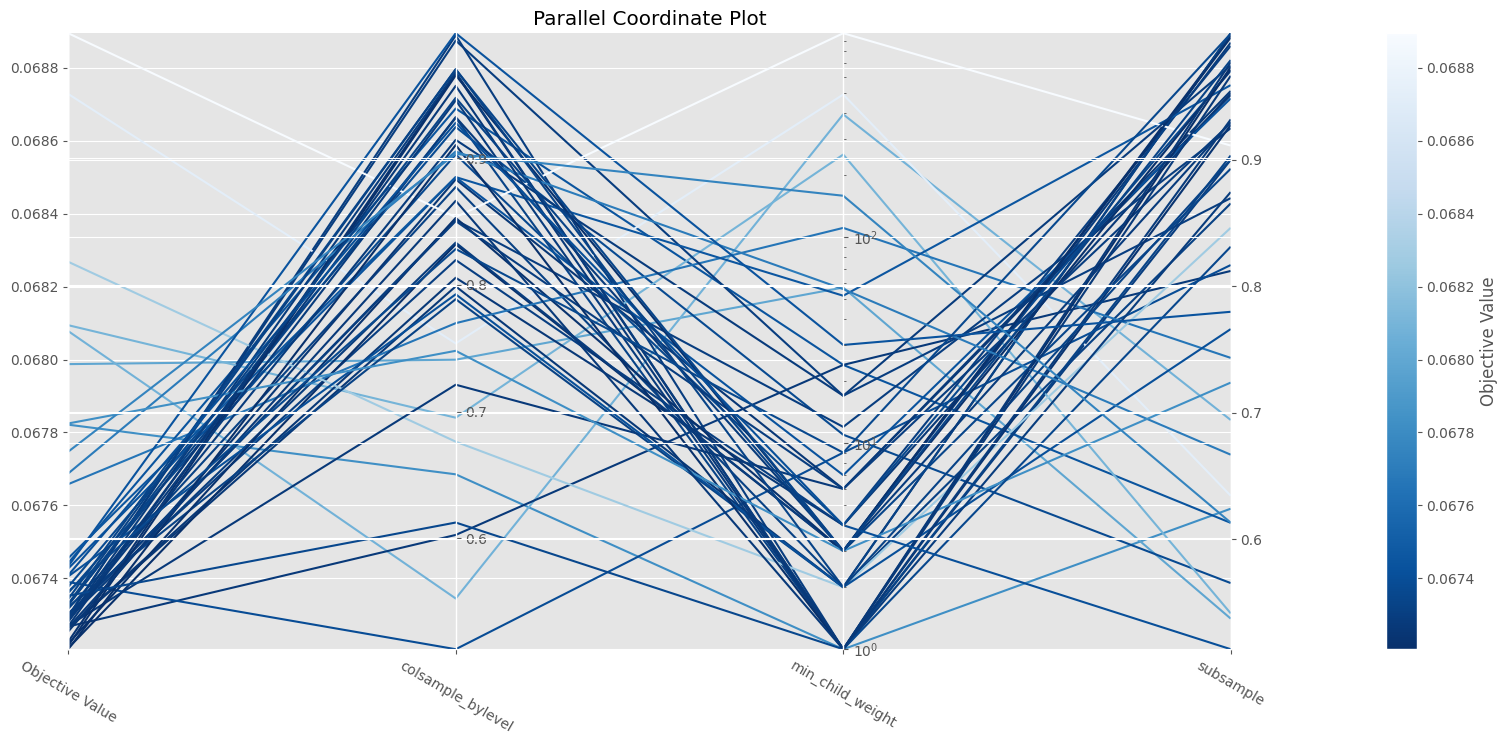

<Figure size 2000x800 with 0 Axes>

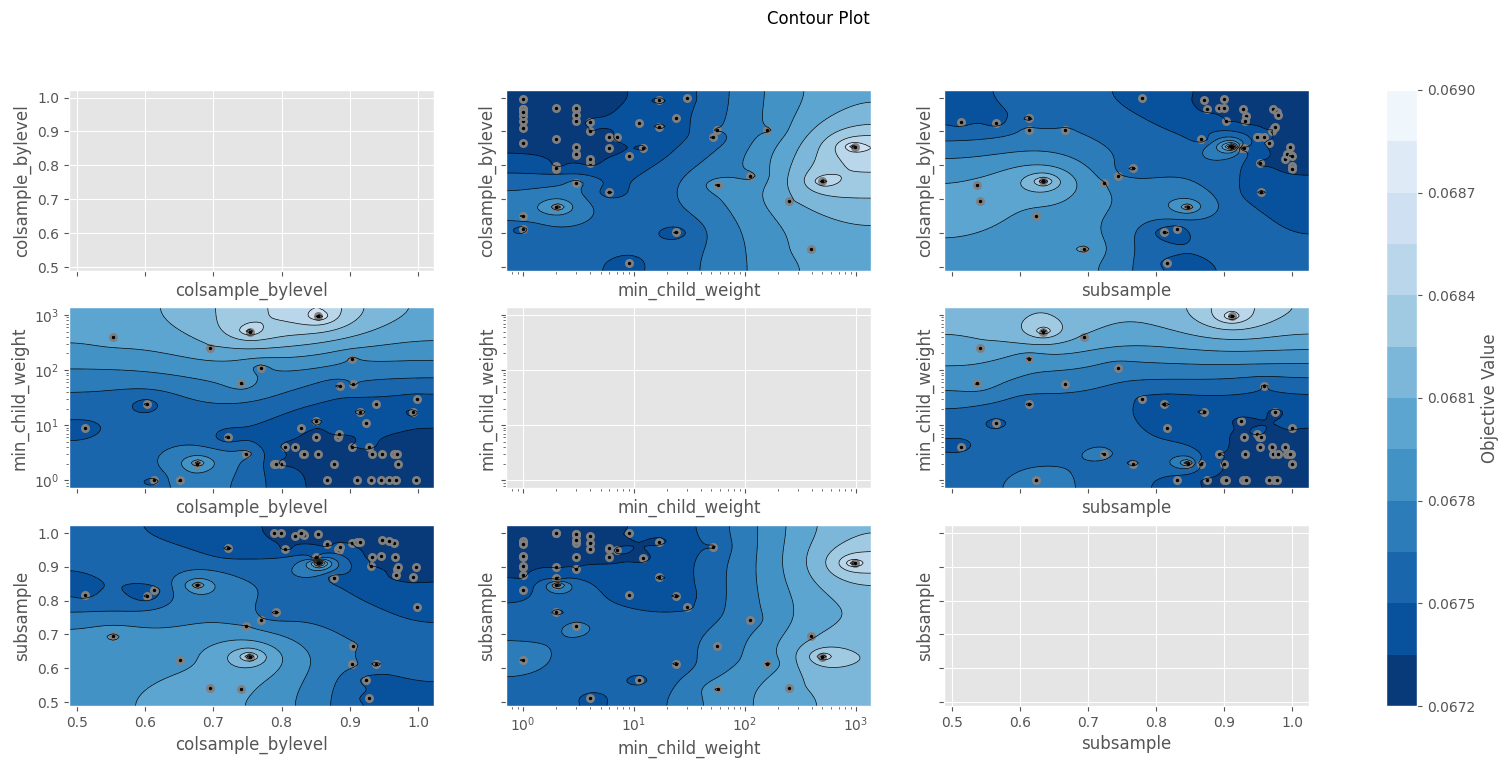

<Figure size 2000x800 with 0 Axes>

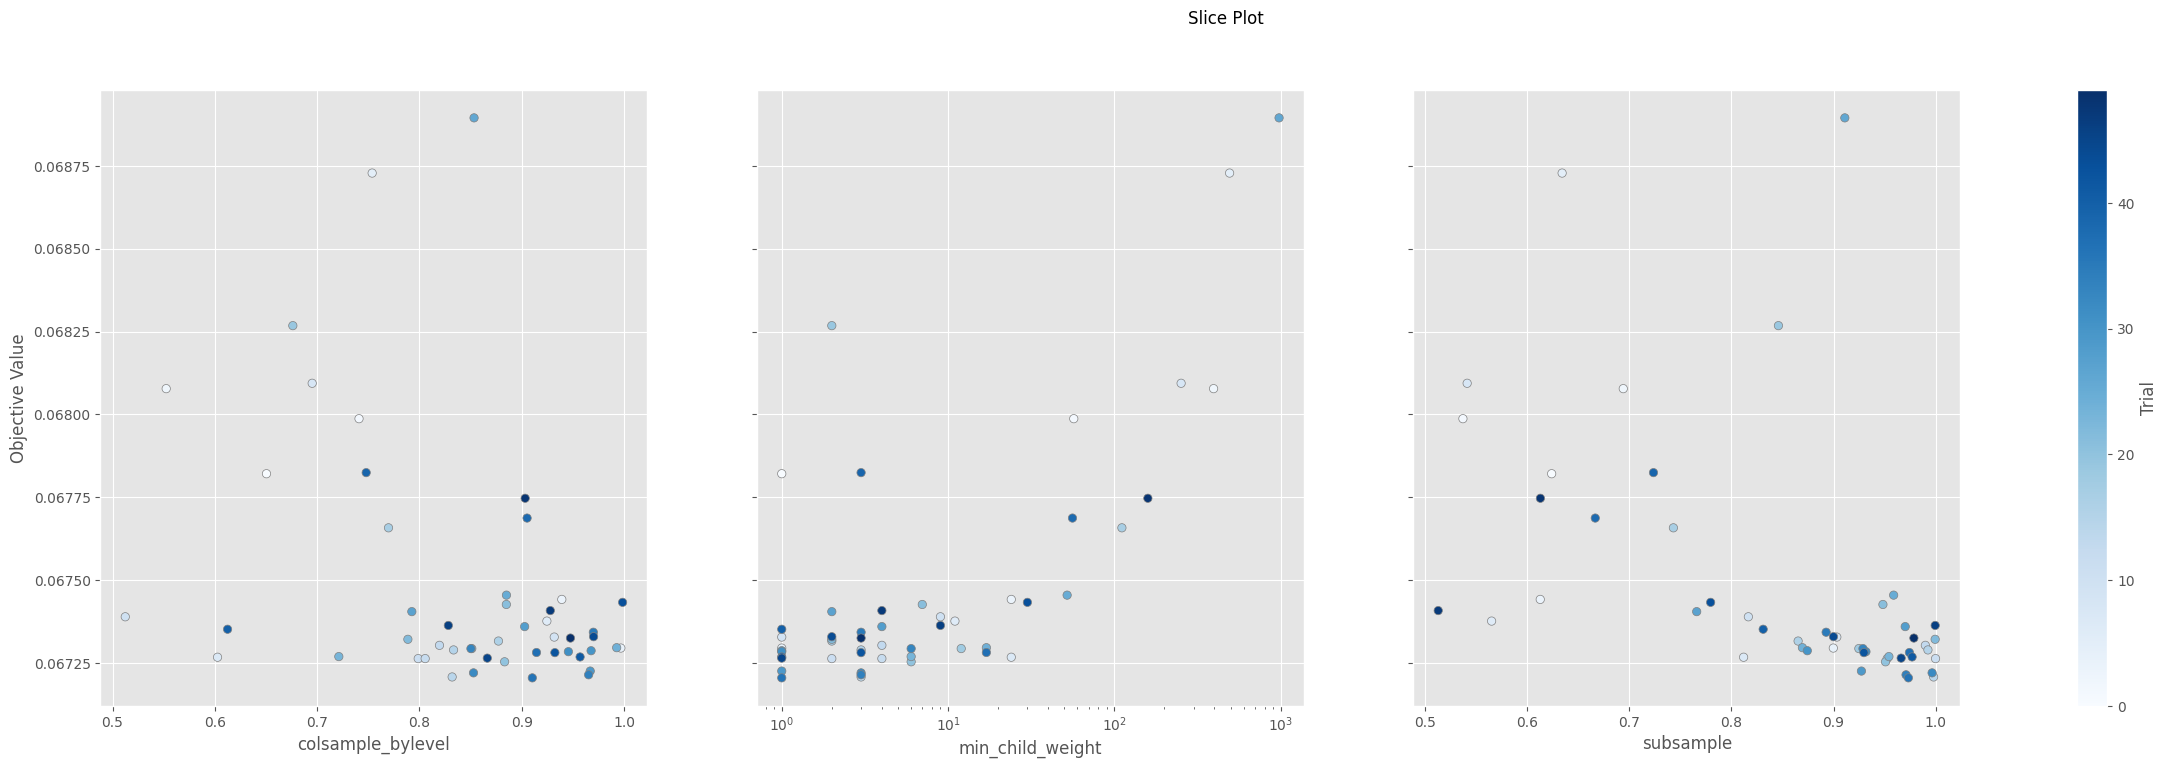

In [ ]:
param_importance = optuna.importance.get_param_importances(study)

plt.figure()
plt.rcParams["figure.figsize"] = [20, 8]
optunampl.plot_parallel_coordinate(study, params=list(param_importance)[:3])

plt.figure()
plt.rcParams["figure.figsize"] = [20, 8]
optunampl.plot_contour(study, params=list(param_importance)[:3])

plt.figure()
plt.rcParams["figure.figsize"] = [20, 8]
optunampl.plot_slice(study, params=list(param_importance)[:3])

### Tune # trees

In [12]:
study_df = pd.read_excel(f"{modelling_log}", "XGB_Tune")
best_params = study_df.sort_values("value").filter(regex="params_").iloc[0].to_dict()
best_params = {k.replace("params_", ""): v for k, v in best_params.items()}
best_params["max_depth"] = int(best_params["max_depth"])
print(best_params)

{'colsample_bylevel': 0.864314455892444, 'colsample_bytree': 0.9672270124844424, 'gamma': 7.940734920911675e-05, 'max_depth': 2, 'min_child_weight': 433.0, 'subsample': 0.8619457541936248}


In [ ]:
###########################################################################
###########################################################################

all_params = {
    "eta": eta, 
    "tree_method": tree_method, 
    "objective": xgb_objective,
    "eval_metric": metric,
    "device": device,
    "seed": seed,
    **best_params
}

verbose = 100

###########################################################################
###########################################################################

xgb_cv = xgb.cv(
    dtrain=dtrain, 
    params=all_params, 
    seed=seed, 
    num_boost_round=num_boost_round, 
    metrics=metric, 
    early_stopping_rounds=early_stopping_round, 
    folds=folds,
    verbose_eval=verbose,
)

[0]	train-poisson-nloglik:0.61537+0.00175	test-poisson-nloglik:0.61537+0.00699
[100]	train-poisson-nloglik:0.11488+0.00100	test-poisson-nloglik:0.11497+0.00388
[200]	train-poisson-nloglik:0.07768+0.00098	test-poisson-nloglik:0.07784+0.00395
[300]	train-poisson-nloglik:0.07348+0.00097	test-poisson-nloglik:0.07369+0.00386
[400]	train-poisson-nloglik:0.07185+0.00093	test-poisson-nloglik:0.07216+0.00373
[500]	train-poisson-nloglik:0.07073+0.00094	test-poisson-nloglik:0.07110+0.00362
[600]	train-poisson-nloglik:0.07003+0.00091	test-poisson-nloglik:0.07045+0.00359
[700]	train-poisson-nloglik:0.06948+0.00091	test-poisson-nloglik:0.06996+0.00354
[800]	train-poisson-nloglik:0.06911+0.00090	test-poisson-nloglik:0.06963+0.00353
[900]	train-poisson-nloglik:0.06878+0.00088	test-poisson-nloglik:0.06934+0.00353
[1000]	train-poisson-nloglik:0.06853+0.00089	test-poisson-nloglik:0.06913+0.00350
[1100]	train-poisson-nloglik:0.06832+0.00089	test-poisson-nloglik:0.06895+0.00349
[1200]	train-poisson-nloglik

Text(0.5, 1.0, 'Cross-Validaeted Deviance Loss by Number of Trees')

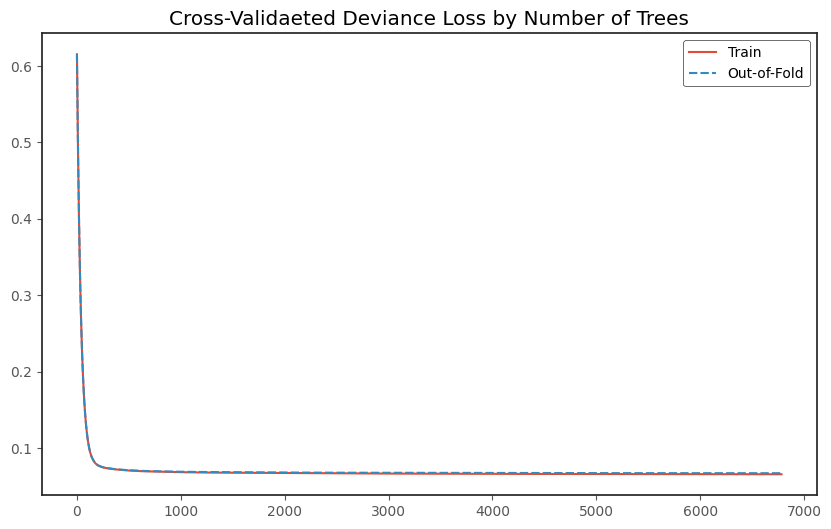

In [ ]:
xgb_cv.rename(
    columns={f"train-{metric}-mean": "Train", f"test-{metric}-mean": "Out-of-Fold"}, 
    inplace=True,
)

plt.rcParams["axes.edgecolor"] = "0.15"
plt.rcParams["axes.linewidth"]  = 1.25
plt.rcParams["figure.figsize"] = [10, 6]

fig, ax = plt.subplots(1)

sns.lineplot(
    data=xgb_cv[["Train", "Out-of-Fold"]], 
    ax=ax, 
)

ax.grid(False)
ax.set_facecolor("white")

ax.legend(facecolor="white", edgecolor="black")
ax.set_title(f"Cross-Validaeted Deviance Loss by Number of Trees")

## Train the XGB model

In [ ]:
best_iteration = len(xgb_cv)
bst = xgb.train(all_params, dtrain, best_iteration)

bst.save_model(xgb_output)

### Holdout Model Performance

In [31]:
bst = xgb.Booster()
bst.load_model(xgb_output)

In [32]:
####################################################################
####################################################################

xgb_rate = "ypred_xgb_death_rate"
xgb_count = "ypred_xgb_death_count"

####################################################################
####################################################################

ypred_test = bst.predict(dtest)
ypred_test_df = pd.DataFrame(ypred_test, columns=[xgb_count], index=X_test.index)
ypred_test_df = ypred_test_df.join(start_test).join(y_test).join(model_data[exposure])
ypred_test_df[xgb_rate] = ypred_test_df[xgb_count] / ypred_test_df[exposure]
ypred_test_df["ypred_death_rate_rel"] = (
    ypred_test_df[gam_rel_death] / ypred_test_df[exposure]
)
ypred_test_df

,ypred_xgb_death_count,ypred_death_count_rel,Death_Count,Policies_Exposed,ypred_xgb_death_rate,ypred_death_rate_rel
unique_id,,,,,,
24,1.843926,1.785105,2.0,4290.800011,0.000430,0.000416
25,1.805290,1.582546,2.0,3059.967118,0.000590,0.000517
26,8.403254,8.544420,7.0,4212.210949,0.001995,0.002028
27,1.837710,2.011335,1.0,413.895889,0.004440,0.004860
28,1.386438,1.178949,0.0,443.816434,0.003124,0.002656
...,...,...,...,...,...,...
575740,0.012136,0.021453,0.0,0.221918,0.054686,0.096671
575744,0.014851,0.010514,0.0,0.624658,0.023775,0.016832
575746,0.005844,0.002867,0.0,0.369863,0.015801,0.007751


In [33]:
gam_dev = utils.total_poisson_dev(
    y=ypred_test_df[act_death], 
    y_pred=ypred_test_df[gam_rel_death],
)
xgb_dev = utils.total_poisson_dev(
    y=ypred_test_df[act_death], 
    y_pred=ypred_test_df[xgb_count],
)

print(f"{'GAM (Single-Factor)':<20}: {gam_dev:,.0f}")
print(f"{'XGBoost':<20}: {xgb_dev:,.0f}")

GAM (Single-Factor) : 101,690
XGBoost             : 100,616


In [34]:
corr, _ = pearsonr(
    ypred_test_df["ypred_xgb_death_rate"], ypred_test_df["ypred_death_rate_rel"]
)
print(f"Correlation between GAM Rel and SOA Expected Death Rate: {corr:.2%}")

Correlation between GAM Rel and SOA Expected Death Rate: 87.27%


In [35]:
################################################################
################################################################

# Define the list of new to current model prediction column names
predict = [xgb_count, gam_rel_death]

################################################################
################################################################

d = utils.DoubleLift(
    ypred_test_df, predict, "Death_Count", exposure, [0.01, 0.95], approx_num_band=25
)

mape_xgb = mean_absolute_percentage_error(
    d.double_lift_table["Death_Count"],
    d.double_lift_table[predict[0]],
    sample_weight=d.double_lift_table[exposure],
)
mape_gam = mean_absolute_percentage_error(
    d.double_lift_table["Death_Count"],
    d.double_lift_table[predict[1]],
    sample_weight=d.double_lift_table[exposure],
)
print(f"{'MAPE - XGB':<30}: {mape_xgb:.2%}")
print(f"{'MAPE - GAM Rel':<30}: {mape_gam:.2%}")

d.double_lift_table

MAPE - XGB                    : 3.17%
MAPE - GAM Rel                : 8.23%


,ratio_band,Death_Count,ypred_xgb_death_count,ypred_death_count_rel,Policies_Exposed
band,,,,,
1,<= 0.7,0.005566,0.003331,0.005873,9.363630e+05
2,"(0.7, 0.8]",0.002610,0.002451,0.003224,1.349630e+06
3,"(0.8, 0.9]",0.002973,0.002948,0.003421,5.157590e+06
4,"(0.9, 1.0]",0.002133,0.002132,0.002246,1.834314e+07
5,"(1.0, 1.1]",0.001841,0.001922,0.001843,1.233514e+07
6,"(1.1, 1.2]",0.002725,0.002803,0.002448,3.863215e+06
7,"(1.2, 1.3]",0.002897,0.003006,0.002412,1.996081e+06
8,"(1.3, 1.4]",0.003773,0.004040,0.003003,1.030475e+06
9,"(1.4, 1.5]",0.003833,0.003971,0.002750,6.979220e+05


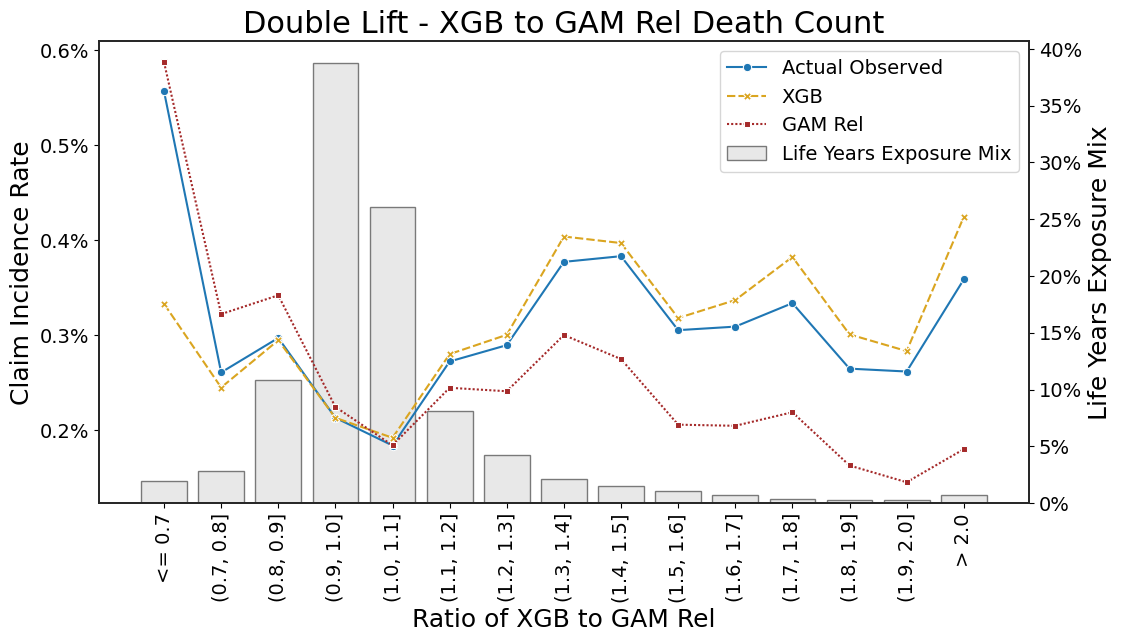

In [36]:
###########################################################################
###########################################################################

param_dict = {
    "title": "Double Lift - XGB to GAM Rel Death Count", 
    "leftylabel": "Claim Incidence Rate", 
    "rightylabel": "Life Years Exposure Mix",
    "target_legend": "Actual Observed", 
    "new_model_legend": "XGB",
    "baseline_legend": "GAM Rel",
    "palette": ["tab:blue", "#DAA520", "#A52A2A"]
}

###########################################################################
###########################################################################

plt.rcParams["axes.edgecolor"] = "0.15"
plt.rcParams["axes.linewidth"] = 1.25

fig, ax = plt.subplots(figsize=(12, 6))

d.plot_double_lift(ax=ax, **param_dict)

## Model Explanation 
### Feature Importance

In [37]:
###########################################################################
###########################################################################

importance_type = "total_gain"

###########################################################################
###########################################################################

xgb_imp_df = pd.DataFrame( 
    bst.get_score(importance_type=importance_type).items(), 
    columns=["Feature", "Importance"]
)

# Clean up the feature name
xgb_imp_df["Feature_Agg"] = (
    xgb_imp_df["Feature"].str.split(".").str[0]
)
xgb_imp_df["Feature_Agg"] = (
    xgb_imp_df["Feature_Agg"]
    .str.replace("_cat_level", "")
    .str.replace("_level", "")
)

# Aggregate the importance dataframe 
xgb_imp_df_agg = (
    xgb_imp_df.groupby(
        ["Feature_Agg"], as_index=False
    )[["Importance"]].sum()
)
xgb_imp_df_agg.sort_values("Importance", inplace=True, ascending=False)

xgb_imp_df_agg["Importance_Norm"] = (
    xgb_imp_df_agg["Importance"] / xgb_imp_df_agg["Importance"].sum()
)
xgb_imp_df_agg

,Feature_Agg,Importance,Importance_Norm
2,Face_Amount_Band_ordinal,32735.021484,0.402133
0,Attained_Age_Sync,16546.791016,0.203269
1,Duration,12688.751953,0.155875
5,Smoker_Status,10967.262329,0.134727
3,Observation_Year,4424.848145,0.054357
4,Sex,4040.777100,0.049639


Text(0.5, 1.0, 'XGB Factor Importance')

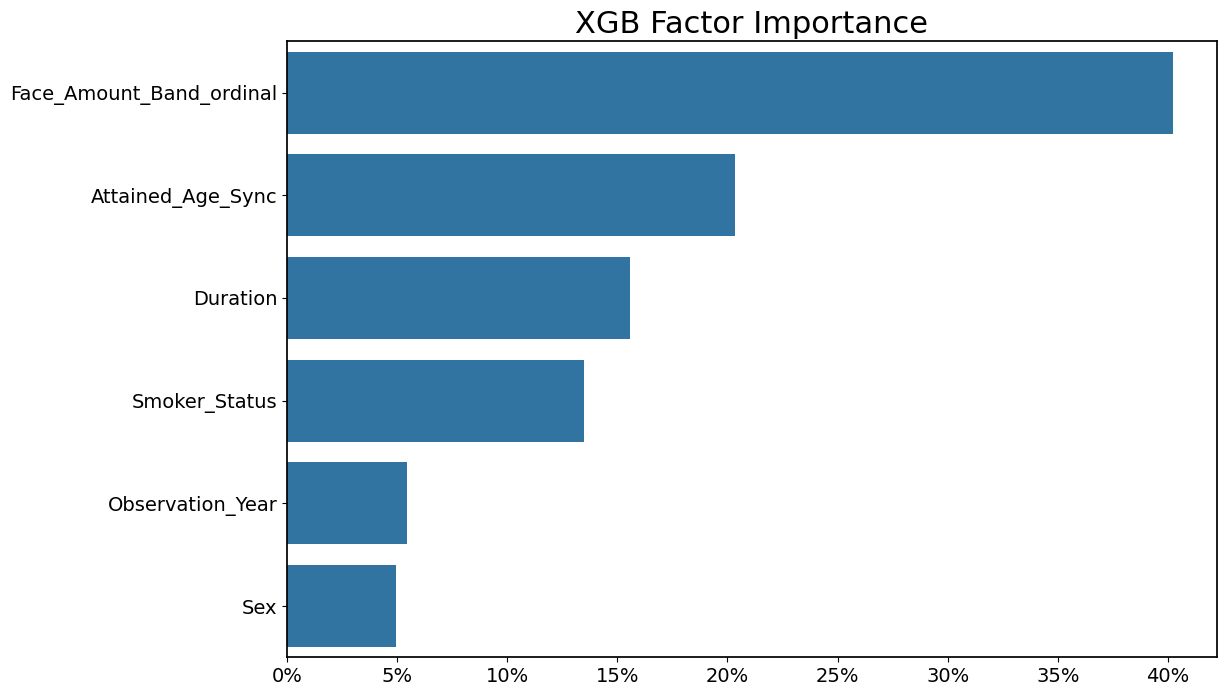

In [38]:
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["axes.edgecolor"] = "black"

fig, ax = plt.subplots(1)

sns.barplot(
    data=xgb_imp_df_agg, 
    y="Feature_Agg", 
    x="Importance_Norm", 
    color="tab:blue", 
    ax=ax,
)

# Do some formating in the x and y axes to make them easier to read
xticker = ax.get_xticks() 
xlabel = [f'{x:,.0%}' for x in xticker]
ax.set_xticklabels(xlabel, fontsize=tick_fontsize)

ylabel = xgb_imp_df_agg["Feature_Agg"] 
ax.set_yticklabels(ylabel, fontsize=tick_fontsize)

ax.set_facecolor("white")

ax.set_xlabel("")
ax.set_ylabel("")

ax.set_title("XGB Factor Importance", fontsize=title_fontsize)

### Actual vs Expected Analysis on Holdout

In [42]:
##################################################################
##################################################################

key_features = [
    "Observation_Year",
    "Sex",
    "Smoker_Status",
    "Duration",
    "Face_Amount_Band",
    "Attained_Age_Sync",
]

##################################################################
##################################################################

# Initialise an empty dict for holding the grouped by dataframes
risk_agg_dict = {}

for v in key_features:
    # Perform risk aggregations by individual features
    df_gb = utils.risk_agg(
        ypred_test_df.join(model_data[key_features]),
        v,
        exposure,
        act_death,
        gam_rel_death_count=gam_rel_death,
        xgb_death_count=xgb_count,
    )
    # We're doing Actual vs Expected analysis
    df_gb["gam_rel_death_rate"] = df_gb["actual_death_rate"] / df_gb["gam_rel_death_rate"]
    df_gb["xgb_death_rate"] = df_gb["actual_death_rate"] / df_gb["xgb_death_rate"]

    risk_agg_dict[v] = df_gb

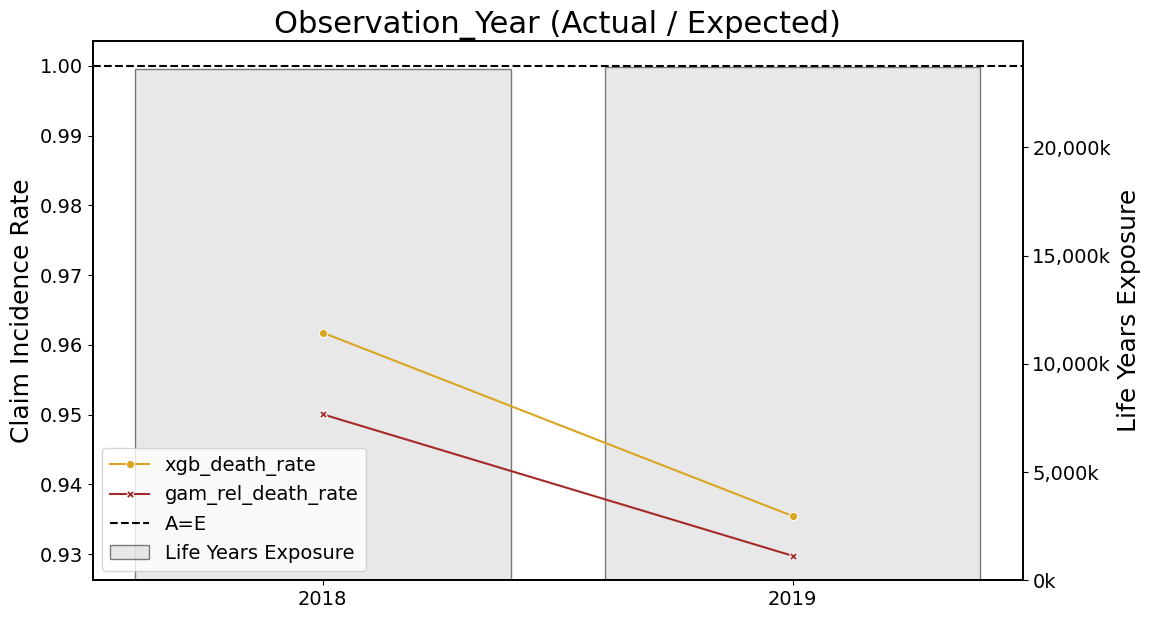

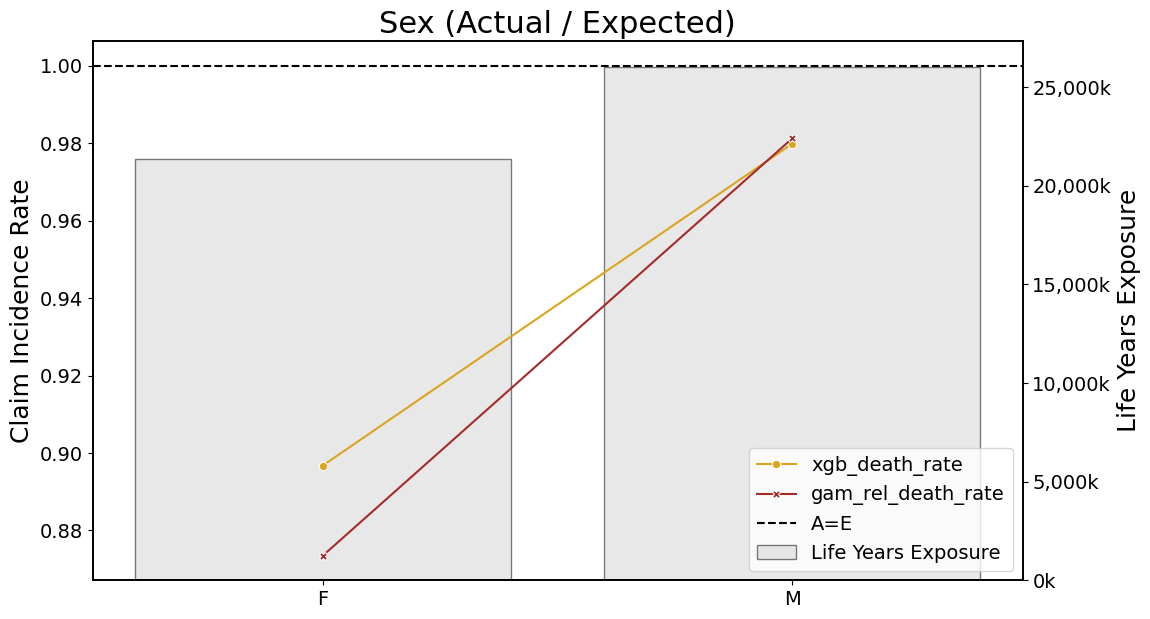

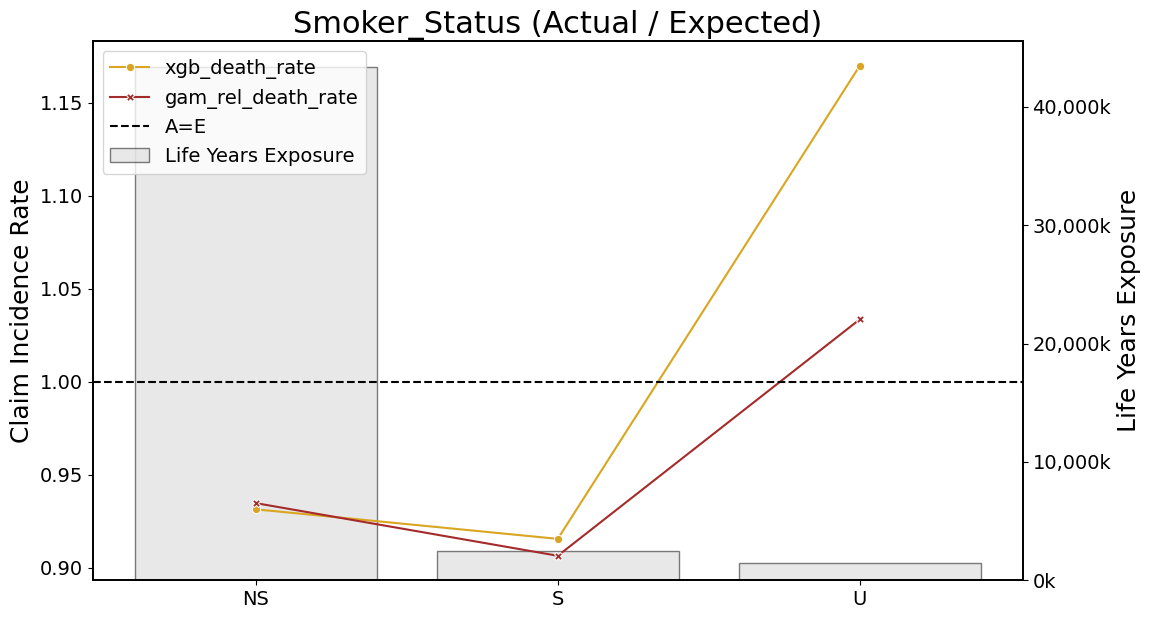

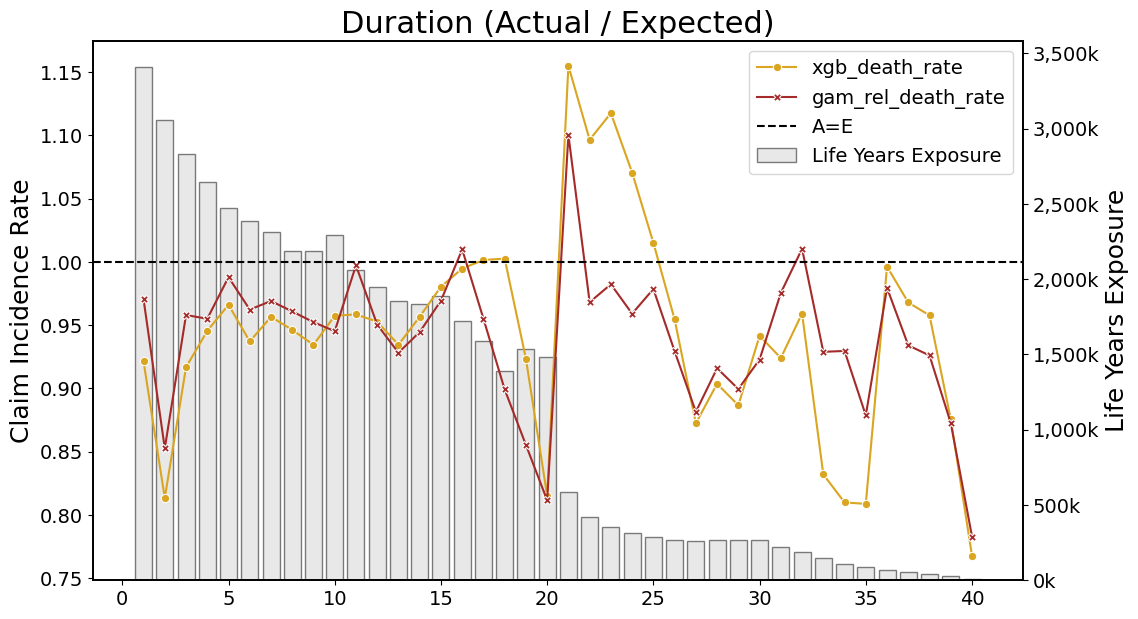

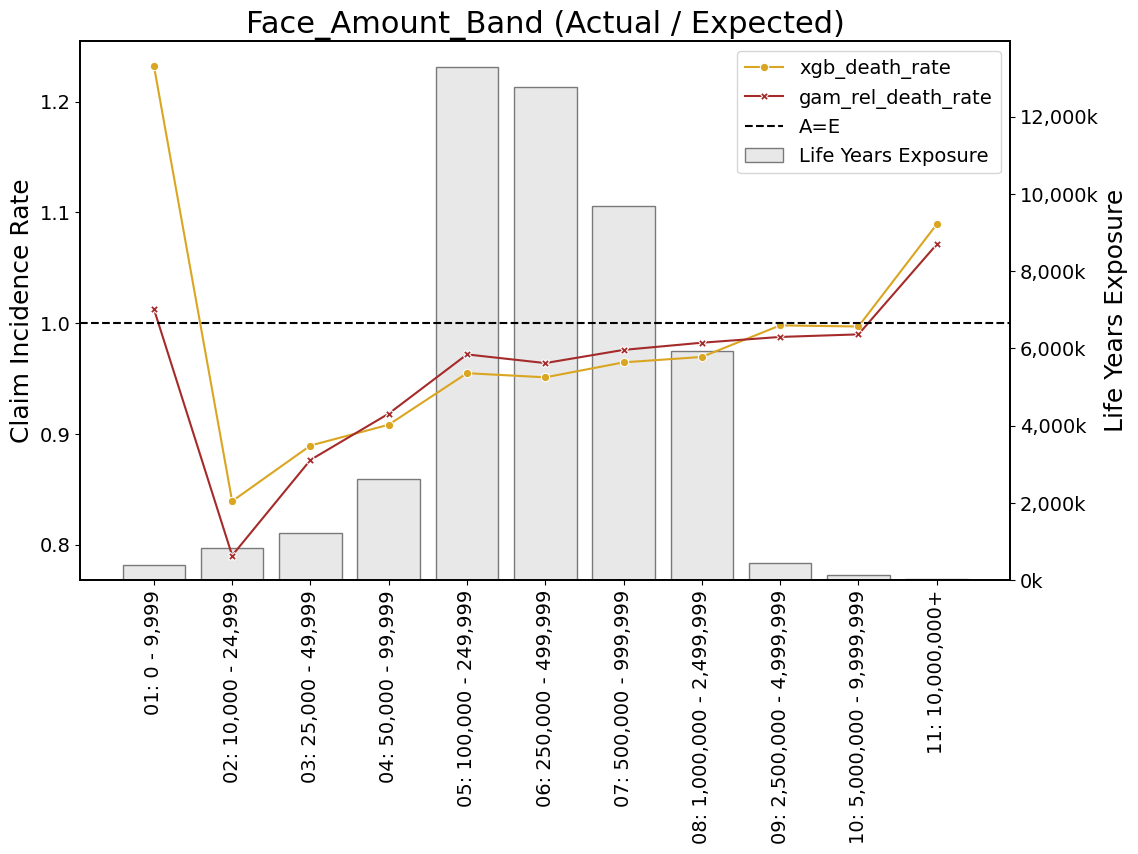

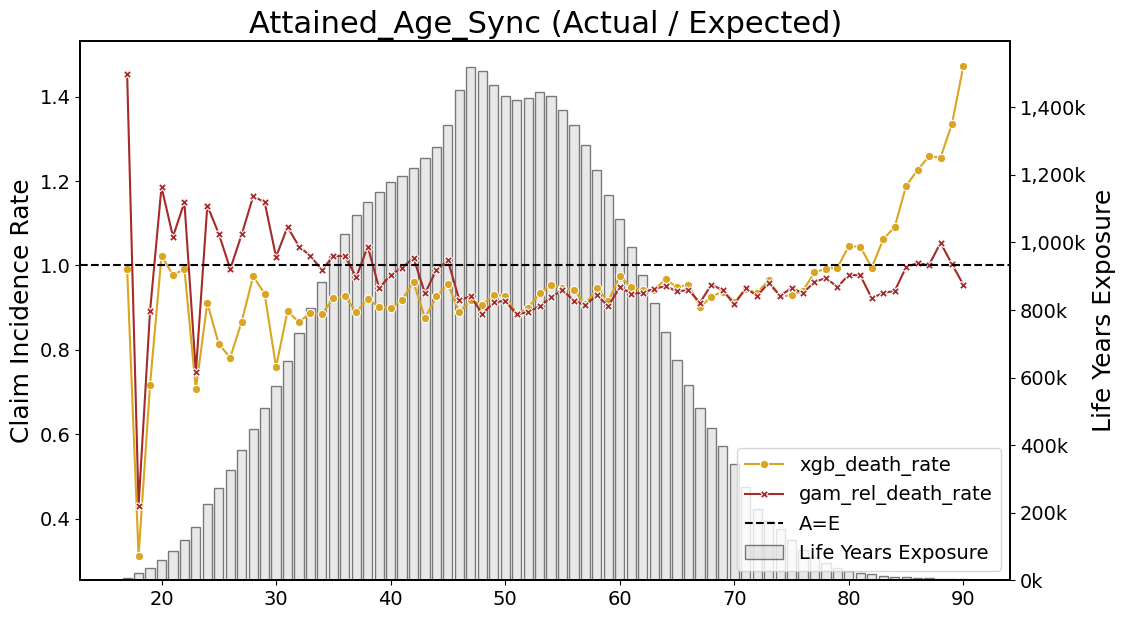

In [47]:
##############################################################################################
##############################################################################################

y1_label = "Claim Incidence Rate"
y2_label = "Life Years Exposure"

##############################################################################################
##############################################################################################

for var in key_features:

    fig, ax = plt.subplots(1, figsize=(12, 7))
    # Plot incidence rates
    sns.lineplot(
        data=risk_agg_dict[var].loc[
            :, ["xgb_death_rate", "gam_rel_death_rate"]
        ],
        ax=ax,
        markers=True,
        dashes=False,
        palette=["#DAA520", "#A52A2A"],
    )
    ax.axhline(y=1, color="black", linestyle="--", label="A=E")

    # Set title and x and y axes labels and fontsize
    ax.set_ylabel(y1_label, fontsize=label_fontsize)
    ax.set_xlabel("")
    ax.set_title(var + " (Actual / Expected)", fontsize=title_fontsize)
    ax.tick_params(axis="both", which="major", labelsize=tick_fontsize)

    # Fix the xticker labels if there are decimal places in xtickers when variable should be integers
    if not isinstance(risk_agg_dict[var].index[0], str):
        index_has_decimals = any(val % 1 != 0 for val in risk_agg_dict[var].index)
        ticks_have_decimals = any(tick % 1 != 0 for tick in ax.get_xticks())

        if not index_has_decimals and ticks_have_decimals:
            ax.set_xticks(risk_agg_dict[var].index)
            ax.set_xticklabels(risk_agg_dict[var].index)

    # Format x-axis tickers
    ax.tick_params(
        axis="x",
        rotation=(
            90
            if isinstance(risk_agg_dict[var].index[0], str)
            and len(risk_agg_dict[var].index[0]) > 4
            else 0
        ),
    )

    # Create secondary y-axis for exposures
    ax2 = ax.twinx()
    ax2.bar(
        risk_agg_dict[var].index,
        risk_agg_dict[var][exposure],
        color="lightgray",
        alpha=0.5,
        ec="k",
        label=y2_label,
    )

    # Format secondary y-axis ticker
    ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1000:,.0f}k"))
    ax2.tick_params(axis="y", which="major", labelsize=tick_fontsize)

    # Combine legends
    lines, labels = ax.get_legend_handles_labels()
    bars, bar_labels = ax2.get_legend_handles_labels()
    ax.legend(
        lines + bars,
        labels + bar_labels,
        loc="best",
        fontsize=tick_fontsize,
        facecolor="white",
    )

    # Set secondary y-axis label
    ax2.set_ylabel(y2_label, fontsize=label_fontsize)

    # Define order of layering
    ax.set_zorder(2)
    ax.patch.set_alpha(0)
    ax2.set_zorder(1)

## Derive interaction importance

<Axes: >

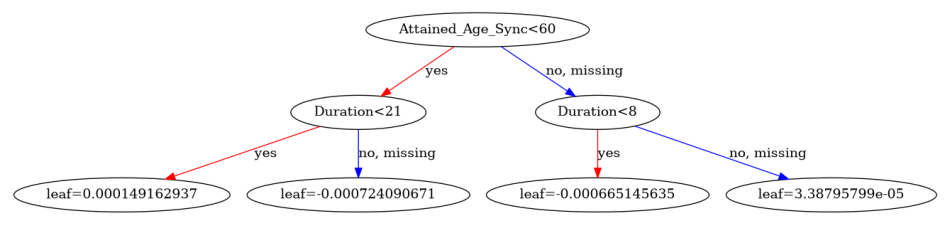

In [48]:
# Plot one tree to visualise it
fig, ax = plt.subplots(figsize=(12, 12))
xgb.plot_tree(bst, num_trees=1999, ax=ax)

In [49]:
# Get the node details
node_df = bst.trees_to_dataframe()

# Clean up the feature name
node_df["Feature"] = (
    node_df["Feature"].str.split(".").str[0]
)
node_df["Feature"] = (
    node_df["Feature"]
    .str.replace("_cat_level", "")
    .str.replace("_level", "")
)
node_df

,Tree,Node,ID,Feature,Split,Yes,No,Missing,Gain,Cover,Category
0,0,0,0-0,Attained_Age_Sync,24.0,0-1,0-2,0-2,1.705042,428922.156000,NaN
1,0,1,0-1,Sex,1.0,0-3,0-4,0-4,32.140148,1169.973390,NaN
2,0,2,0-2,Face_Amount_Band_ordinal,7.0,0-5,0-6,0-6,0.423419,427752.188000,NaN
3,0,3,0-3,Leaf,NaN,NaN,NaN,NaN,-0.011660,490.653625,NaN
4,0,4,0-4,Leaf,NaN,NaN,NaN,NaN,0.005120,679.319763,NaN
...,...,...,...,...,...,...,...,...,...,...,...
48185,7007,2,7007-2,Attained_Age_Sync,36.0,7007-5,7007-6,7007-6,0.589774,228398.750000,NaN
48186,7007,3,7007-3,Leaf,NaN,NaN,NaN,NaN,-0.000130,137196.562000,NaN
48187,7007,4,7007-4,Leaf,NaN,NaN,NaN,NaN,0.000154,62564.066400,NaN
48188,7007,5,7007-5,Leaf,NaN,NaN,NaN,NaN,-0.001508,591.803345,NaN


In [50]:
# Get the parent node for every tree 
node_df_0 = node_df[node_df.Node == 0]

# Join the features used to split in the next level (Yes)
node_df_0_Y = node_df_0.merge(
    node_df[["ID", "Feature", "Gain"]], 
    left_on="Yes", 
    right_on="ID", 
    suffixes=("", "1"),
)
node_df_0_Y = node_df_0_Y[
    node_df_0_Y["Feature1"] != "Leaf"
]
node_df_0_Y = node_df_0_Y[
    node_df_0_Y["Feature"] != node_df_0_Y["Feature1"]
]
node_df_0_Y["Feature_List"] = (
    node_df_0_Y.apply(lambda x: np.sort([x.Feature, x.Feature1]), axis=1)
)
node_df_0_Y = node_df_0_Y[["Feature_List", "Gain1"]]
print(node_df_0_Y.head())

# Join the features used to split in the next level (No)
node_df_0_N = node_df_0.merge(
    node_df[["ID", "Feature", "Gain"]], 
    left_on="No", 
    right_on="ID", 
    suffixes=("", "1"),
)
node_df_0_N = node_df_0_N[
    node_df_0_N["Feature1"] != "Leaf"
]
node_df_0_N = node_df_0_N[
    node_df_0_N["Feature"] != node_df_0_N["Feature1"]
]
node_df_0_N["Feature_List"] = (
    node_df_0_N.apply(lambda x: np.sort([x.Feature, x.Feature1]), axis=1)
)
node_df_0_N = node_df_0_N[["Feature_List", "Gain1"]]
print(node_df_0_N.head())

                                    Feature_List       Gain1
0                       [Attained_Age_Sync, Sex]   32.140148
1  [Attained_Age_Sync, Face_Amount_Band_ordinal]    3.122555
2           [Duration, Face_Amount_Band_ordinal]  369.451874
3           [Duration, Face_Amount_Band_ordinal]   84.435814
4                  [Attained_Age_Sync, Duration]    0.881924
                                    Feature_List       Gain1
0  [Attained_Age_Sync, Face_Amount_Band_ordinal]    0.423419
1  [Attained_Age_Sync, Face_Amount_Band_ordinal]  113.042030
2           [Duration, Face_Amount_Band_ordinal]  136.002350
3                  [Attained_Age_Sync, Duration]    8.557593
4                  [Attained_Age_Sync, Duration]    5.322952


In [51]:
# Aggregate Gains to two-way interactions 
two_way_gain_df = pd.concat([node_df_0_Y, node_df_0_N], axis=0)
two_way_gain_df["Feature_List"] = two_way_gain_df["Feature_List"].apply(
    lambda x: " x ".join(x)
)
two_way_gain_df = two_way_gain_df.groupby(
    ["Feature_List"], as_index=False
)[["Gain1"]].sum()
two_way_gain_df = two_way_gain_df.sort_values("Gain1", ascending=False)
two_way_gain_df["Gain_Norm"] = (
    two_way_gain_df["Gain1"] / two_way_gain_df["Gain1"].sum()
)

Text(0.5, 1.0, 'Interaction Importance')

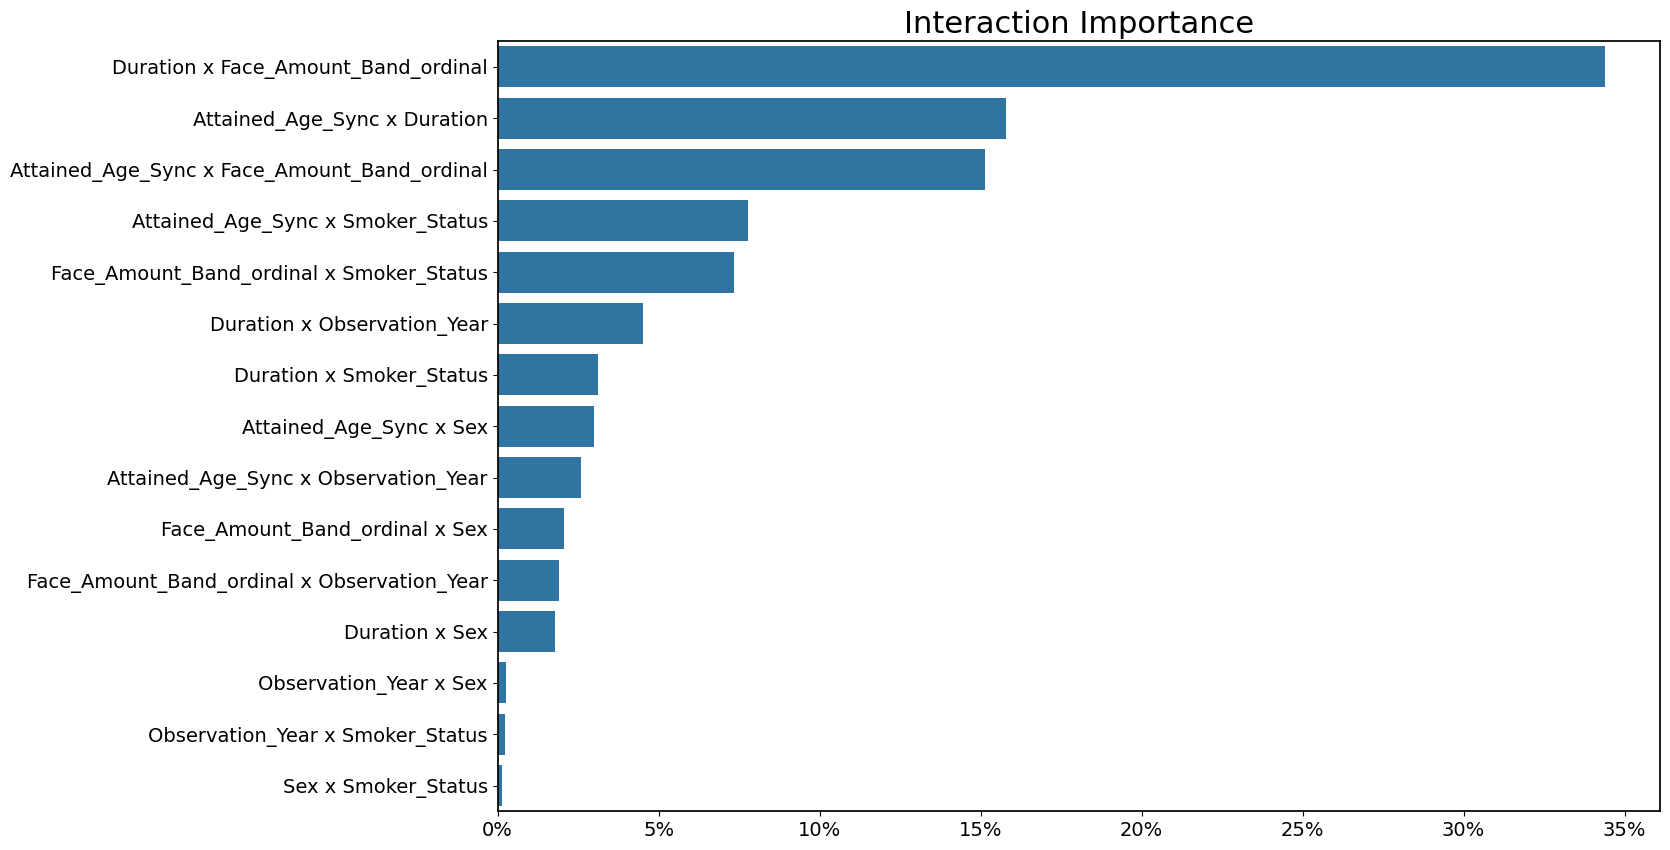

In [52]:
plt.rcParams["figure.figsize"] = (15, 10)
plt.rcParams["axes.edgecolor"] = "black"

fig, ax = plt.subplots(1)

sns.barplot(
    data=two_way_gain_df, 
    y="Feature_List", 
    x="Gain_Norm", 
    color="tab:blue", 
    ax=ax,
)

# Do some formating in the x and y axes to make them easier to read
xticker = ax.get_xticks() 
xlabel = [f'{x:,.0%}' for x in xticker]
ax.set_xticklabels(xlabel, fontsize=tick_fontsize)

ylabel = two_way_gain_df["Feature_List"] 
ax.set_yticklabels(ylabel, fontsize=tick_fontsize)

ax.set_facecolor("white")

ax.set_xlabel("")
ax.set_ylabel("")

ax.set_title("Interaction Importance", fontsize=title_fontsize)

In [53]:
with pd.ExcelWriter(
    f"{modelling_log}", engine="openpyxl", mode="a", if_sheet_exists="replace"
) as writer:
    two_way_gain_df.to_excel(
        writer, sheet_name="Inter_Imp_GBM", index=False
    )